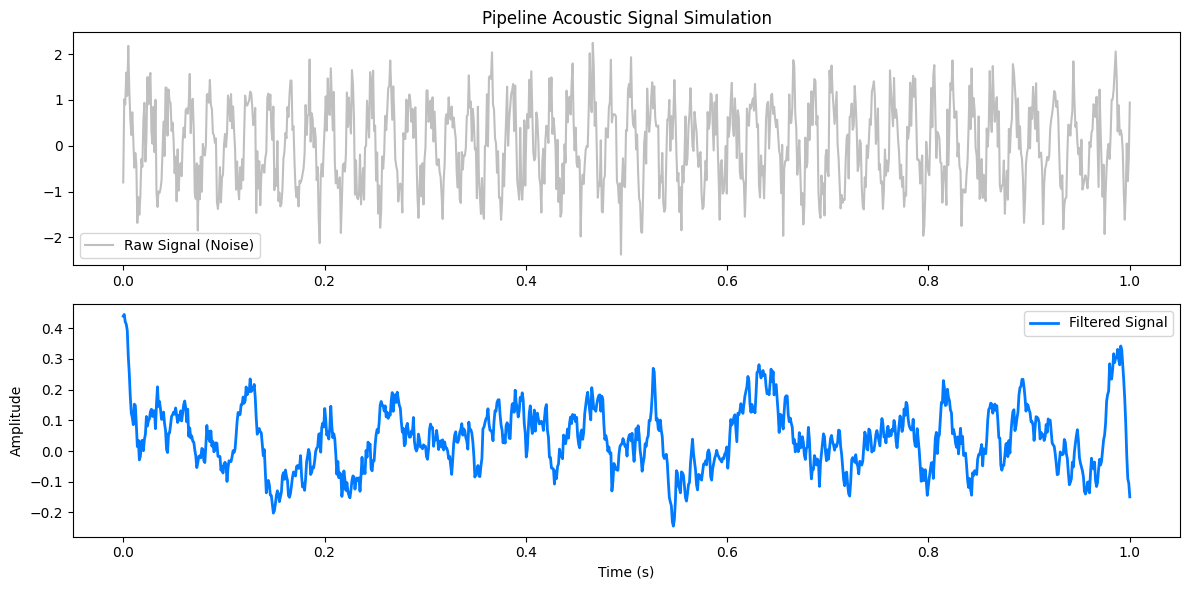

M5 芯片算力测试：信号生成与滤波处理已完成！


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 模拟生成一段管道内的原始声波信号
# 假设采样频率为 1000Hz，持续 1 秒
fs = 1000 
t = np.linspace(0, 1, fs)

# 模拟一个 50Hz 的碰撞信号，并叠加上随机环境噪声
clean_signal = np.sin(2 * np.pi * 50 * t)
noise = 0.5 * np.random.randn(fs)
raw_signal = clean_signal + noise

# 2. 数据处理：简单的移动平均滤波（找回算法感觉）
window_size = 20
filtered_signal = np.convolve(raw_signal, np.ones(window_size)/window_size, mode='same')

# 3. 可视化呈现：让数据变成直观的图形
plt.figure(figsize=(12, 6))

# 画出原始信号（带噪声的）
plt.subplot(2, 1, 1)
plt.plot(t, raw_signal, color='gray', alpha=0.5, label='Raw Signal (Noise)')
plt.title("Pipeline Acoustic Signal Simulation")
plt.legend()

# 画出处理后的信号（滤掉部分噪声）
plt.subplot(2, 1, 2)
plt.plot(t, filtered_signal, color='#007AFF', linewidth=2, label='Filtered Signal')
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()

plt.tight_layout()
plt.show()

print("M5 芯片算力测试：信号生成与滤波处理已完成！")

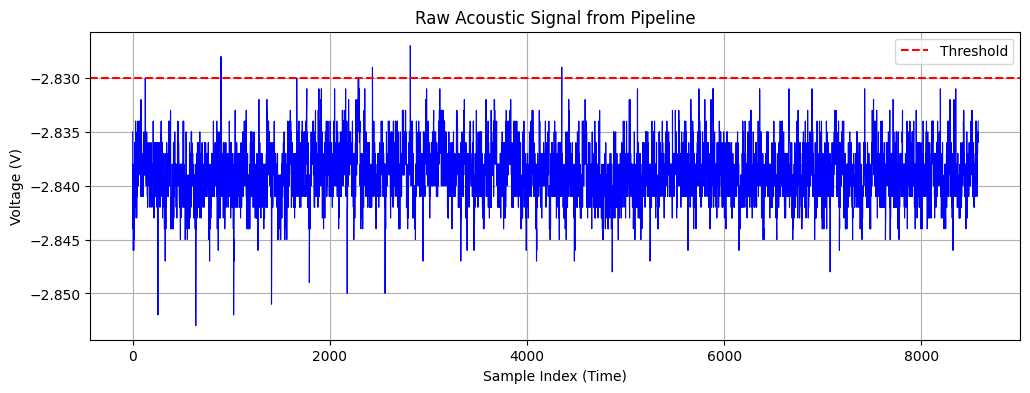

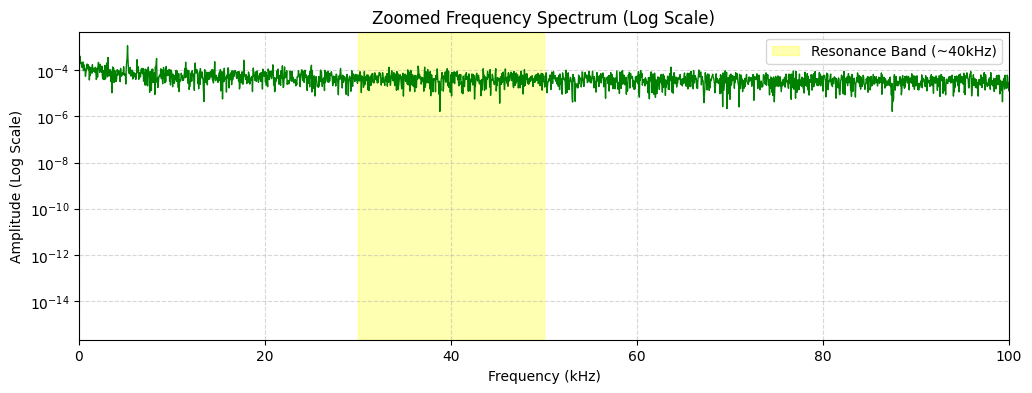

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 打开你刚刚找到的宝藏文件
file_path = '202255945.txt'
with open(file_path, 'r') as file:
    # 把文本里用空格隔开的数字全部读取出来
    data_string = file.read().split()

# 2. 把文字转换成 Python 可以计算的小数（浮点数）数组
signal_array = np.array([float(x) for x in data_string])

# 3. 见证奇迹的时刻：把它画出来！
plt.figure(figsize=(12, 4)) # 设置画布大小
plt.plot(signal_array, color='blue', linewidth=0.8) # 画出蓝色的波形线

# 画一条红色的线作为“阈值”参考（你可以自己调整这根线的位置）
plt.axhline(y=-2.830, color='red', linestyle='--', label='Threshold') 

plt.title('Raw Acoustic Signal from Pipeline') # 图表标题
plt.xlabel('Sample Index (Time)') # 横坐标：时间/采样点
plt.ylabel('Voltage (V)') # 纵坐标：电压值
plt.legend()
plt.grid(True)
plt.show() # 显示图表


############ 频域图

import numpy as np
import matplotlib.pyplot as plt

# 1. 读取数据（和你原来的一样）
file_path = '202255945.txt'
with open(file_path, 'r') as file:
    data_string = file.read().split()
signal_array = np.array([float(x) for x in data_string])

# === 下面是新增的 FFT 频域分析代码 ===

# 关键参数：采样频率 (Sampling Rate)
# 注意：我们要看 800kHz 的信号，根据奈奎斯特定理，采样率至少得是 1600kHz (1.6MHz)。
# 这里我假设现场传感器使用的是 2MHz (2,000,000 Hz) 的高速采样率。
# 如果你知道现场准确的采样率，请修改这个值！
fs = 400000 #2000000  

# 获取数据长度
N = len(signal_array)

# 去除信号的直流分量（让信号均值为0，消除0Hz处的巨大干扰峰）
signal_zero_mean = signal_array - np.mean(signal_array)

# 执行快速傅里叶变换 (FFT)
fft_y = np.fft.fft(signal_zero_mean)
# 计算对应的频率轴
fft_x = np.fft.fftfreq(N, 1/fs)

# 我们只取正半轴的频率和对应的振幅
half_n = N // 2
freqs = fft_x[:half_n] / 1000  # 把 Hz 转换成 kHz，方便看图
amplitudes = np.abs(fft_y[:half_n]) * 2.0 / N

# 画出频域图
# === 替换原来的画图部分 ===
plt.figure(figsize=(12, 4))
plt.plot(freqs, amplitudes, color='green', linewidth=1)
plt.title('Zoomed Frequency Spectrum (Log Scale)')
plt.xlabel('Frequency (kHz)')
plt.ylabel('Amplitude (Log Scale)')

# 【绝杀招式 1】把 Y 轴变成对数坐标，微弱的高频信号瞬间凸显！
plt.yscale('log') 

# 【绝杀招式 2】屏蔽低频噪音的干扰，我们直接把 X 轴视野限制在 100kHz 到 1000kHz 之间
plt.xlim(0 ,100) 

# 把之前高亮 600-800 的代码删掉，换成高亮 30-50kHz 附近（传感器的 40kHz 共振区）
plt.axvspan(30, 50, color='yellow', alpha=0.3, label='Resonance Band (~40kHz)')

plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5) # 让网格更细致一点
plt.show()

In [2]:
import numpy as np
from scipy.signal import find_peaks

# 【第一步：脱水去噪 (对应公式里的 sp - sb)】
# 1. 算出本底噪声 sb (取这段信号的平均值，大概是 -2.839V 左右)
baseline_noise = np.mean(signal_array) 

# 2. 原始信号减去噪声，并取绝对值，得到纯净的波动幅度！
# 现在，水流的噪音变成了 0，砂子的撞击变成了正数的尖刺
clean_signal = np.abs(signal_array - baseline_noise)


# 【第二步：捕捉砂粒 (对应界面上的 Threshold 和 IPS)】
# 1. 设置阈值 (Threshold)：假设波动幅度超过 0.005V 才算是砂子
threshold_value = 0.005 

# 2. 呼叫 Python 的核武器：find_peaks (寻找波峰)
# 它会自动帮你从 clean_signal 里找出所有高度大于 threshold_value 的尖刺！
# peaks 里面保存的是这些尖刺在数组里的位置(索引)
peaks, _ = find_peaks(clean_signal, height=threshold_value)

# 3. 算出 IPS (每秒冲击次数)
ips = len(peaks) # 找出了几个波峰，就是撞击了几次！


# 【第三步：计算出砂质量 (对应 PPT 第211页的公式 M)】
# 公式复习: M = (1 / K*v^2) * ∫(sp - sb)^2 dt [1]

# 1. 提取所有被判定为砂子的波峰信号能量
sand_signals = clean_signal[peaks] 

# 2. 积分计算：把信号“平方”后“求和” (对应公式里的 ∫(sp - sb)^2 )
signal_energy_integral = np.sum(sand_signals ** 2)

# 3. 引入物理参数进行“解耦”
K = 1.5 # 假设导师给你的标定经验系数是 1.5
v = 2.0 # 假设当前管道里的水流速度是 2.0 m/s

# 4. 最终算出砂量 (瞬时出砂率 g/s)
mass = (1 / (K * (v ** 2))) * signal_energy_integral


# 【打印最终结果！】
print("-" * 30)
print(f"检测到的本底噪声基线: {baseline_noise:.4f} V")
print(f"砂粒冲击次数 (IPS): {ips} 次")
print(f"计算得出的瞬时出砂量: {mass:.6f} 克")
print("-" * 30)

------------------------------
检测到的本底噪声基线: -2.8388 V
砂粒冲击次数 (IPS): 266 次
计算得出的瞬时出砂量: 0.001864 克
------------------------------


一共找到了 63 个文件，正在拼命计算中...


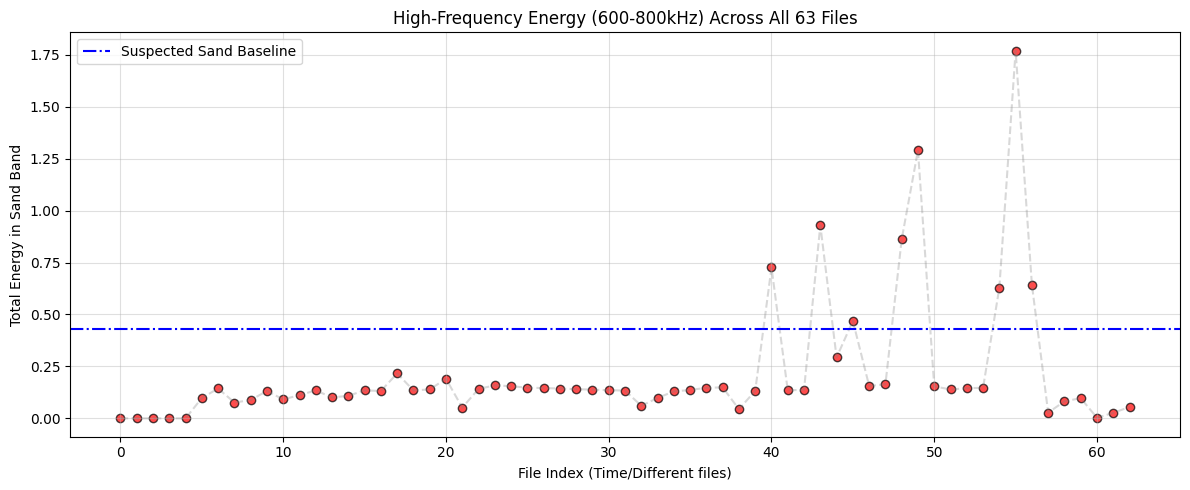


🚨 嫌疑最大的三个（可能是真实出砂）文件是：
Top 1: 2022551658.txt (能量值: 1.76999)
Top 2: 2022551652.txt (能量值: 1.29063)
Top 3: 2022551646.txt (能量值: 0.92944)


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# 1. 找到你存放所有 txt 文件的文件夹（假设你放在了 'data' 文件夹下）
# 如果 txt 和代码在同一个文件夹，直接用 file_list = glob.glob('*.txt')
# 使用 Mac 环境下的绝对路径（注意外面用双引号，里面保留星号通配符）
file_list = glob.glob("/Volumes/LKs' disk/中海油能源发展装备公司海上油气管道含砂监测技术应用研究/结题资料/现场数据/*.txt")

# 准备一个空列表，用来装每个文件的“高频能量值”
high_freq_energies = []
file_names = []

fs = 2000000  # 假设采样率 2MHz

print(f"一共找到了 {len(file_list)} 个文件，正在拼命计算中...")

# 2. 开始循环处理每一个文件
for file_path in file_list:
    try:
        with open(file_path, 'r') as file:
            data_string = file.read().split()
        
        signal_array = np.array([float(x) for x in data_string])
        N = len(signal_array)
        
        if N == 0:
            continue
            
        # 消除直流分量并做 FFT
        signal_zero_mean = signal_array - np.mean(signal_array)
        fft_y = np.fft.fft(signal_zero_mean)
        fft_x = np.fft.fftfreq(N, 1/fs)
        
        half_n = N // 2
        freqs = fft_x[:half_n] / 1000  # 转换为 kHz
        amplitudes = np.abs(fft_y[:half_n]) * 2.0 / N
        
        # 👑 核心算法：只提取 600kHz 到 800kHz 之间的能量
        band_mask = (freqs >= 600) & (freqs <= 800)
        # 将这个频段内的振幅求和（代表高频总能量）
        band_energy = np.sum(amplitudes[band_mask]) 
        
        high_freq_energies.append(band_energy)
        file_names.append(os.path.basename(file_path)) # 记住文件名，方便一会抓内鬼
        
    except Exception as e:
        print(f"处理文件 {file_path} 时出错: {e}")

# 3. 画出宏观统计的散点图！
plt.figure(figsize=(12, 5))
# 用散点图画出这 60 多个文件的能量分布
plt.scatter(range(len(high_freq_energies)), high_freq_energies, color='red', alpha=0.7, edgecolors='black')
plt.plot(range(len(high_freq_energies)), high_freq_energies, color='gray', alpha=0.3, linestyle='--')

plt.title('High-Frequency Energy (600-800kHz) Across All 63 Files')
plt.xlabel('File Index (Time/Different files)')
plt.ylabel('Total Energy in Sand Band')

# 画一条动态的区分基准线（你可以根据跑出来的图自己调整）
mean_energy = np.mean(high_freq_energies)
plt.axhline(y=mean_energy * 2, color='blue', linestyle='-.', label='Suspected Sand Baseline')

plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# 揪出嫌疑犯：打印出能量最高的前 3 个文件
sorted_indices = np.argsort(high_freq_energies)[::-1]
print("\n🚨 嫌疑最大的三个（可能是真实出砂）文件是：")
for i in range(min(3, len(sorted_indices))):
    idx = sorted_indices[i]
    print(f"Top {i+1}: {file_names[idx]} (能量值: {high_freq_energies[idx]:.5f})")

🎯 侦测到疑似砂粒撞击！发生时间: 第 333.59 毫秒


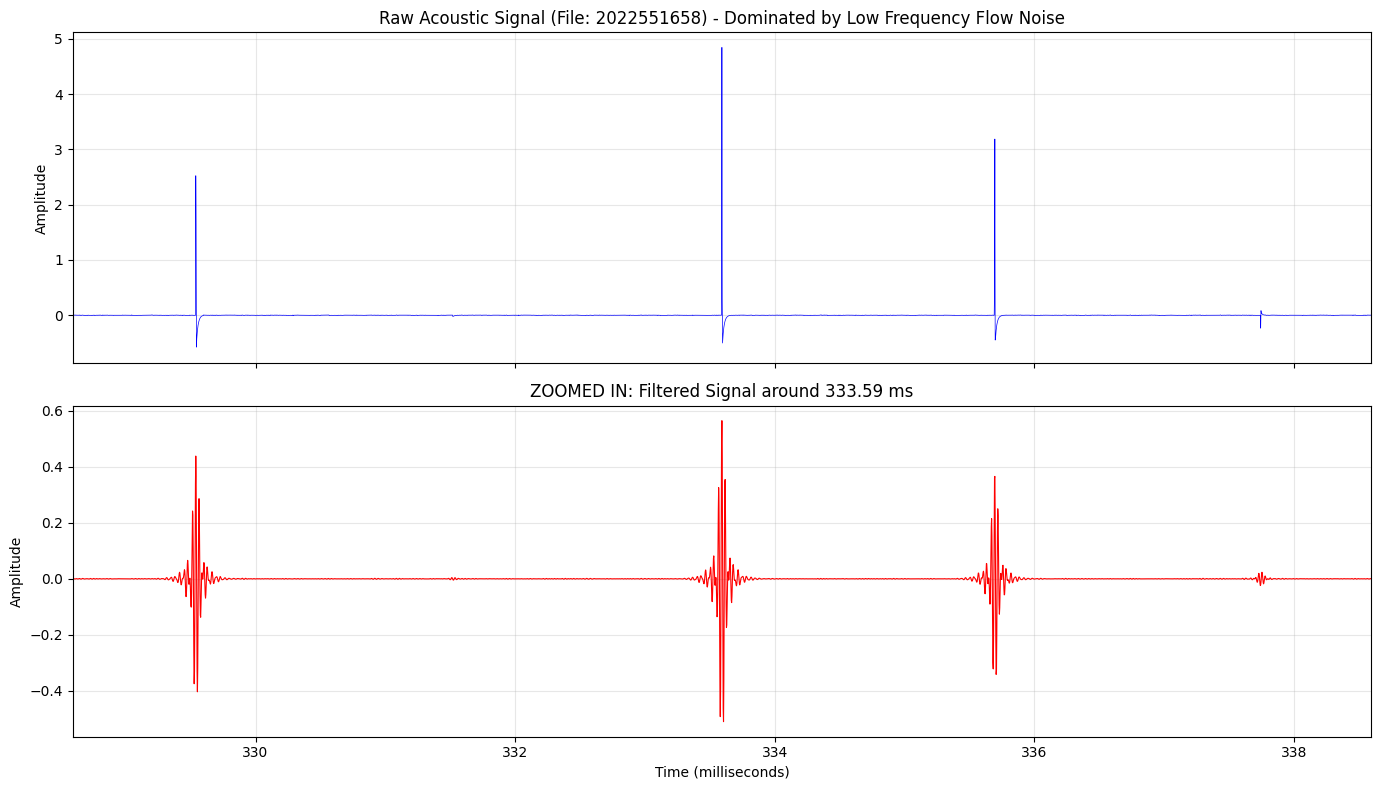

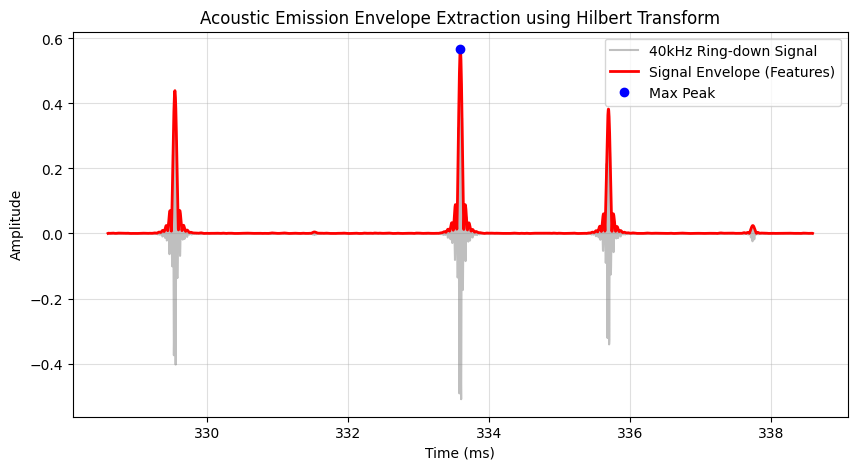

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

file_path = "/Volumes/LKs' disk/中海油能源发展装备公司海上油气管道含砂监测技术应用研究/结题资料/现场数据/2022551658.txt" 

# --- 硬件参数 ---
fs = 400000  # 真实采样率 400kHz
lowcut = 30000.0  # 滤波下限 30kHz
highcut = 50000.0 # 滤波上限 50kHz

# 2. 读取数据
with open(file_path, 'r') as file:
    data_string = file.read().split()
signal_raw = np.array([float(x) for x in data_string])
signal_raw = signal_raw - np.mean(signal_raw) # 去直流

# 3. 设计巴特沃斯带通滤波器 (Butterworth Bandpass Filter)
def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs  # 奈奎斯特频率 (200kHz)
    low = lowcut / nyq
    high = highcut / nyq
    # 生成滤波器参数 b, a
    b, a = butter(order, [low, high], btype='band')
    # 使用 filtfilt 进行零相位滤波（防止信号变形）
    y = filtfilt(b, a, data)
    return y

# 执行滤波，洗出纯净的砂粒信号！
signal_filtered = butter_bandpass_filter(signal_raw, lowcut, highcut, fs)

# 生成时间轴（以毫秒为单位方便查看）
time_ms = np.arange(len(signal_raw)) / fs * 1000

# 4. 见证奇迹：画图对比
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# 图1：原始信号（混杂了大量的低频流体噪音）
ax1.plot(time_ms, signal_raw, color='blue', linewidth=0.5)
ax1.set_title(f'Raw Acoustic Signal (File: 2022551658) - Dominated by Low Frequency Flow Noise')
ax1.set_ylabel('Amplitude')
ax1.grid(True, alpha=0.3)

# 图2：滤波后的纯净砂粒信号
ax2.plot(time_ms, signal_filtered, color='red', linewidth=0.8)
ax2.set_title('Filtered Signal (30kHz - 50kHz Bandpass) - Sand Impact Signatures Revealed!')
ax2.set_xlabel('Time (milliseconds)')
ax2.set_ylabel('Amplitude')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
# === 在原来的代码后面，plt.tight_layout() 的前面加入这段 ===

# 1. 自动定位：找到滤波后信号绝对值最大（能量最强）的那个点的索引
max_idx = np.argmax(np.abs(signal_filtered))
peak_time_ms = time_ms[max_idx]  # 算出这个点发生在哪一毫秒

print(f"🎯 侦测到疑似砂粒撞击！发生时间: 第 {peak_time_ms:.2f} 毫秒")

# 2. 拿显微镜看：强行把 X 轴的视野，限制在这个最高点的前后 5 毫秒！
# 这就相当于放大了 100 倍！
ax2.set_xlim(peak_time_ms - 5, peak_time_ms + 5)
ax1.set_xlim(peak_time_ms - 5, peak_time_ms + 5)

ax2.set_title(f'ZOOMED IN: Filtered Signal around {peak_time_ms:.2f} ms')
plt.show()

from scipy.signal import hilbert

# === 在你刚才画特写图的代码后面加上这段 ===

# 1. 截取特写窗口内的数据（只分析这 10 毫秒的纺锤）
# 找到 peak_time_ms 前后 5 毫秒的数据索引
zoom_mask = (time_ms >= peak_time_ms - 5) & (time_ms <= peak_time_ms + 5)
time_zoomed = time_ms[zoom_mask]
signal_zoomed = signal_filtered[zoom_mask]

# 2. 核心数学魔法：希尔伯特变换提取“包络线”
analytic_signal = hilbert(signal_zoomed)
amplitude_envelope = np.abs(analytic_signal)

# 3. 画出最终的特征提取图！
plt.figure(figsize=(10, 5))

# 画出高频震荡的真实信号（灰色，作为背景）
plt.plot(time_zoomed, signal_zoomed, color='gray', alpha=0.5, label='40kHz Ring-down Signal')

# 画出提取出来的完美“纺锤形紧身衣”（红色粗线，这是喂给AI的核心！）
plt.plot(time_zoomed, amplitude_envelope, color='red', linewidth=2, label='Signal Envelope (Features)')

plt.title('Acoustic Emission Envelope Extraction using Hilbert Transform')
plt.xlabel('Time (ms)')
plt.ylabel('Amplitude')

# 标记出最大振幅点
max_env_idx = np.argmax(amplitude_envelope)
plt.plot(time_zoomed[max_env_idx], amplitude_envelope[max_env_idx], 'bo', label='Max Peak')

plt.legend()
plt.grid(True, alpha=0.4)
plt.show()